In [62]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, r2_score
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

plt.rcParams.update({
    "axes.titlesize": 20,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
})

In [63]:
# ---------------------------
# 0. Load data
# ---------------------------
df = pd.read_csv("../data/patient_features_with_encounter_cluster.csv")

df['encounter_start_dt'] = pd.to_datetime(df['encounter_start_dt'], errors='coerce')
df['encounter_end_dt']   = pd.to_datetime(df['encounter_end_dt'],   errors='coerce')

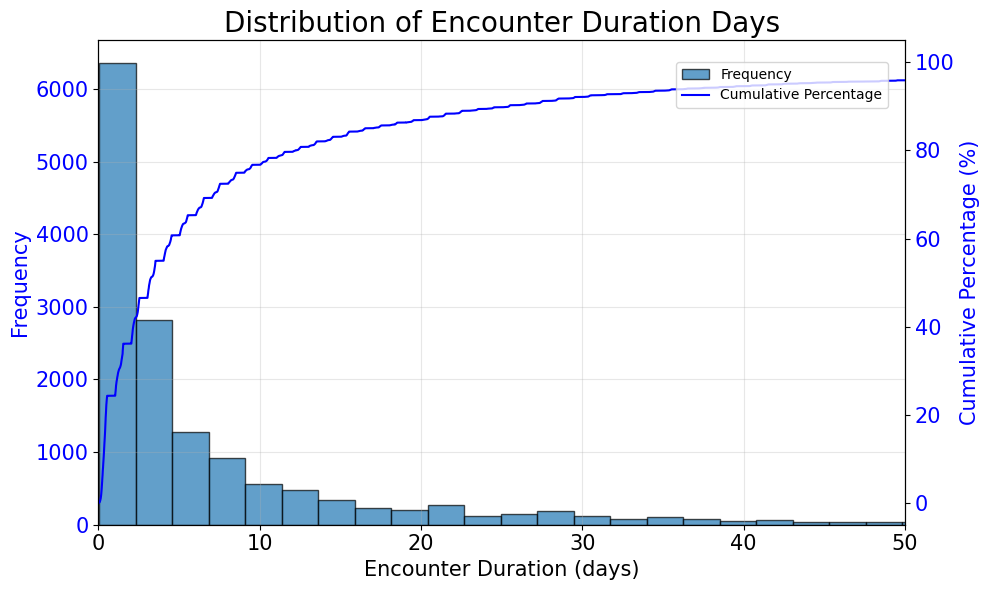

In [64]:
data = df['encounter_duration_days'].dropna()

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.hist(data, bins=100, edgecolor='black', alpha=0.7, label='Frequency')
ax1.set_xlabel('Encounter Duration (days)', size=15)
ax1.set_ylabel('Frequency', color='blue', size=15)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 50)

ax2 = ax1.twinx()
data_sorted = data.sort_values()
y = np.arange(1, len(data_sorted) + 1) / len(data_sorted) * 100 
ax2.plot(data_sorted, y, color='blue', label='Cumulative Percentage')
ax2.set_ylabel('Cumulative Percentage (%)', color='blue', size=15)
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Distribution of Encounter Duration Days', size=20)
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.savefig("figures/los/encounter_duration_days_distribution.png")


In [65]:
# Use icd_prefix3_unique_str, encode and binarize and use for training
df["icd_prefix3_unique_str"] = df.icd_prefix3_unique_str.fillna("").apply(
    lambda x: [str(code).strip() for code in x.split("|")] if x else []
)

mlb = MultiLabelBinarizer(sparse_output=True)
proc_code_mlb = mlb.fit_transform(df["icd_prefix3_unique_str"])
codes_df = pd.DataFrame.sparse.from_spmatrix(
    proc_code_mlb,
    columns=mlb.classes_,
    index = df.index
)

mlb_columns = [i for i in list(mlb.classes_) if i not in df.columns.to_list()]
# additional_columns = list(tfidf.get_feature_names_out()) + list(mlb.classes_)
additional_columns = list(set(mlb_columns))
all_df = pd.concat([df, codes_df[mlb_columns]], axis=1)


In [66]:
# Use proc codes and description, encode and binarize and use for training
all_columns = ['patient_id', 'encounter_id', 'icd_prefix3_unique_str', 'n_icd_prefix3',
       'encounter_start_dt', 'encounter_end_dt', 'encounter_duration_days',
       'encounter_setting', 'encounter_medical_service',
       'adt_event_types_seq_str', 'adt_event_times_seq_str',
       'PATIENT_BIRTH_YEAR', 'PATIENT_SEX', 'PATIENT_RACE_ETHNICITY',
       'DECEASED_FLAG', 'age', 'med_order_nunique', 'proc_codes_seq_str',
       'proc_descs_seq_str', 'proc_times_seq_str', 'proc_count',
       'past_num_encounters', 'past_total_procedures', 'past_total_icd_codes',
       'past_total_encounter_days', 'encounter_cluster']
df["proc_code_seq_list"] = df.proc_codes_seq_str.fillna("").apply(
    lambda x: [str(code).strip() for code in x.split("|")] if x else []
)

mlb = MultiLabelBinarizer(sparse_output=True)
proc_code_mlb = mlb.fit_transform(df["proc_code_seq_list"])

codes_df = pd.DataFrame.sparse.from_spmatrix(
    proc_code_mlb,
    columns=mlb.classes_,
    index = df.index
)

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df = 5,
    max_features = 2000,
    stop_words="english"
)
proc_desc_tfidf = tfidf.fit_transform(df["proc_descs_seq_str"].fillna("").tolist())
desc_df = pd.DataFrame.sparse.from_spmatrix(
    proc_desc_tfidf,
    columns=tfidf.get_feature_names_out(),
    index = df.index
)

tfidf_columns = [i for i in list(tfidf.get_feature_names_out()) if i not in df.columns.to_list()]
mlb_columns = [i for i in list(mlb.classes_) if i not in df.columns.to_list()]
# additional_columns = list(tfidf.get_feature_names_out()) + list(mlb.classes_)
additional_columns = list(set(mlb_columns + tfidf_columns))
all_df = pd.concat([df, codes_df[mlb_columns], desc_df[tfidf_columns]], axis=1)


In [67]:
# ---------------------------
# 2. Feature sets
#    Remove encounter_setting; keep encounter_medical_service (categorical).
#    Cluster version adds 'encounter_cluster'.
# ---------------------------

base_features = [
    'age', 'PATIENT_SEX', 'PATIENT_RACE_ETHNICITY',
    'encounter_medical_service', 'n_icd_prefix3',
    'past_num_encounters', 'past_total_procedures',
    'past_total_icd_codes', 'past_total_encounter_days'
    # DO NOT include encounter_setting
]
base_features    = [c for c in base_features if c in df.columns]


def build_preproc(feature_list):
    # separate categorical and numeric
    cat_cols = [c for c in feature_list if df[c].dtype == 'object']
    num_cols = [c for c in feature_list if c not in cat_cols]

    preproc = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
            ('num', 'passthrough', num_cols)
        ],
        remainder='drop'
    )
    return preproc, cat_cols, num_cols

def fit_and_eval_cls(
        feature_list, y_col, 
        label, df_train, df_test,
        use_additional=False,
        suppress_logs=True,
        ):
    use_cols = feature_list.copy()
    preproc, cat_cols, num_cols = build_preproc(use_cols)
    if use_additional:
        use_cols += additional_columns
    verbose = -1 if suppress_logs else 1
    clf = LGBMClassifier(
        subsample=0.7,
        reg_lambda=1.0,
        reg_alpha=1.0,
        n_estimators=300,
        min_child_samples=5,
        learning_rate=np.float64(0.01),
        num_leaves=31,
        colsample_bytree=1,
        verbosity=verbose,
    )
    pipe = Pipeline([
        ('prep', preproc),
        ('lgbm', clf)
    ])
    X_tr, y_tr = df_train[use_cols], df_train[y_col]
    X_te, y_te = df_test[use_cols],  df_test[y_col]

    pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_te)[:,1]
    pred  = (proba >= 0.5).astype(int)

    auc = roc_auc_score(y_te, proba)
    ap  = average_precision_score(y_te, proba)
    if not suppress_logs:
        print(f"[{label}] Classifier {y_col}: AUC={auc:.3f}, PR-AUC={ap:.3f}")
        print(classification_report(y_te, pred, digits=3))
    return pipe, proba, {'AUC': auc, 'PR_AUC': ap}
    

In [68]:
# ---------------------------
# 3. Train/Test split with GroupKFold (by patient)
#    We first create a single holdout split to report metrics consistently.
# ---------------------------
# Create groups
groups = df['patient_id'].astype(str)
gkf = GroupKFold(n_splits=5)
all_df = df
train_idx, test_idx = next(gkf.split(all_df, groups=groups))

df_train = all_df.iloc[train_idx].reset_index(drop=True)
df_test = all_df.iloc[test_idx].reset_index(drop=True)

In [69]:
# ---------------------------
# 4. Train & evaluate (Base vs Cluster)
# ---------------------------
print("Data shape:", all_df.shape)

results = []
results_df = pd.DataFrame()
target_days = 'encounter_duration_days'

los_to_predict = 20
for long_stay_threshold in range(1, los_to_predict+1):
    df_train['is_long_stay'] = df_train[target_days] >= long_stay_threshold
    df_test['is_long_stay'] = df_test[target_days] >= long_stay_threshold

    base_cls, base_prob_long, base_cls_metrics = fit_and_eval_cls(
        base_features, 'is_long_stay', "Base", 
        df_train, df_test)
    results_df[f"prob_longer_than_{long_stay_threshold}"] = base_prob_long
    results.append((base_prob_long, base_cls_metrics))


Data shape: (15116, 27)


c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\valida

In [70]:
results_df["encounter_start_dt"] = df_test["encounter_start_dt"]
results_df["encounter_medical_service"] = df_test["encounter_medical_service"]
results_df.sort_values("encounter_start_dt", inplace=True)

prob_cols = [f"prob_longer_than_{i}" for i in range(1,los_to_predict+1)]

workloads = (
    results_df.groupby("encounter_start_dt")[prob_cols]
      .sum()
      .reset_index()
)

dates = pd.date_range(
    start=df["encounter_start_dt"].min().normalize(),
    end=df["encounter_start_dt"].max().normalize() + pd.Timedelta(days=len(prob_cols)),
    freq="D",
    tz="UTC"
)

daily_workload = pd.Series(0.0, index=dates)
for _, row in workloads.iterrows():
    encounter_start_dt = row["encounter_start_dt"].normalize()

    for k, col in enumerate(prob_cols):
        workload_date = encounter_start_dt + pd.Timedelta(days=k)
        daily_workload.loc[workload_date] += row[col]
daily_workload_df = (
    daily_workload
    .rename("expected_workload")
    .reset_index()
    .rename(columns={"index": "date"})
)


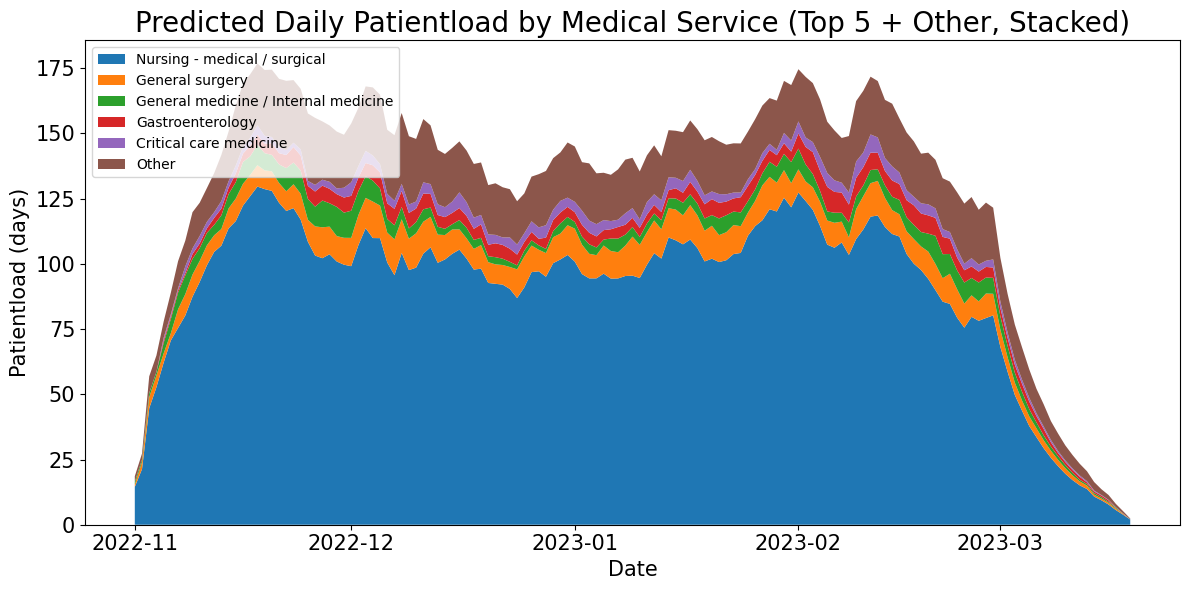

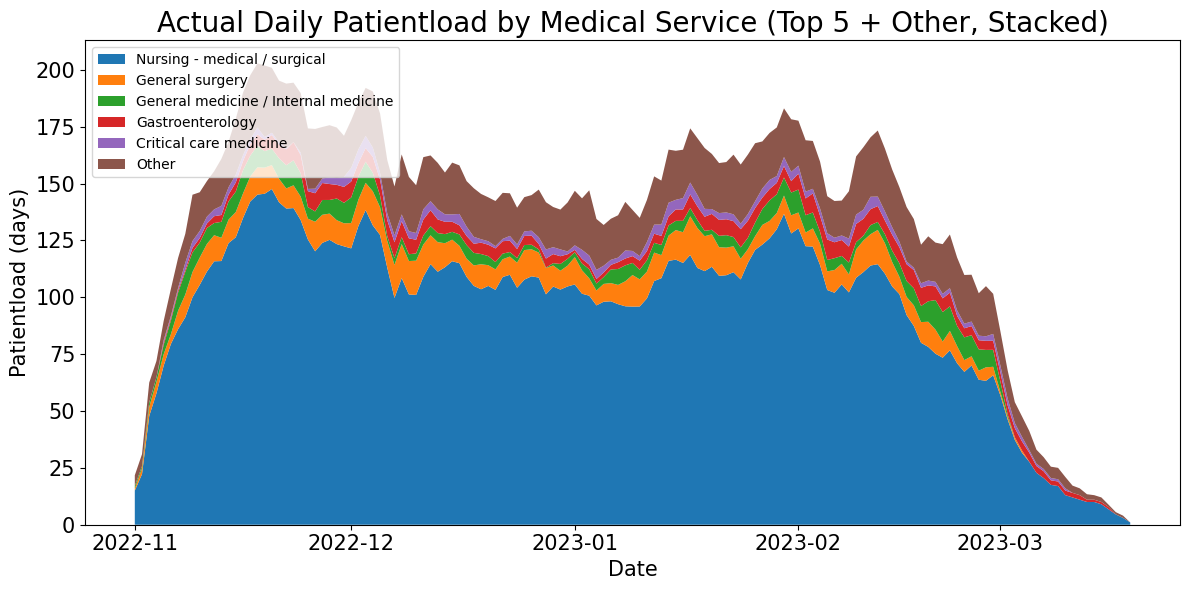

In [71]:
workloads = results_df.groupby(["encounter_start_dt", "encounter_medical_service"])[prob_cols].sum().reset_index()

predicted_contribs = []
for _, row in workloads.iterrows():
    start_dt = row["encounter_start_dt"].normalize()
    service = row["encounter_medical_service"]
    for k, col in enumerate(prob_cols):
        date = start_dt + pd.Timedelta(days=k)
        contrib = row[col]
        predicted_contribs.append({"date": date, "service": service, "workload": contrib})

predicted_df = pd.DataFrame(predicted_contribs).groupby(["date", "service"])["workload"].sum().reset_index()
predicted_pivot = predicted_df.pivot(index="date", columns="service", values="workload").fillna(0)

out = (
    df_test.assign(
        los=lambda d: d["encounter_duration_days"].astype(float).clip(upper=los_to_predict),
        full_days=lambda d: np.floor(d["los"]).astype(int),
        rem=lambda d: d["los"] - np.floor(d["los"]),
        service=lambda d: d["encounter_medical_service"]
    )
)

full_part = (
    out.loc[out["full_days"] > 0, ["encounter_start_dt", "full_days", "service"]]
      .assign(day_offset=lambda d: d["full_days"].apply(lambda n: list(range(n))))
      .explode("day_offset")
      .assign(date=lambda d: d["encounter_start_dt"] + pd.to_timedelta(d["day_offset"].astype(int), unit="D"),
              contrib=1.0)[["date", "service", "contrib"]]
)

rem_part = (
    out.loc[out["rem"] > 0, ["encounter_start_dt", "full_days", "rem", "service"]]
      .assign(date=lambda d: d["encounter_start_dt"] + pd.to_timedelta(d["full_days"], unit="D"),
              contrib=lambda d: d["rem"])[["date", "service", "contrib"]]
)

actual_df = (
    pd.concat([full_part, rem_part], ignore_index=True)
      .groupby(["date", "service"], as_index=False)["contrib"].sum()
      .rename(columns={"contrib": "workload"})
)
actual_pivot = actual_df.pivot(index="date", columns="service", values="workload").fillna(0)

total_predicted_per_service = predicted_pivot.sum(axis=0).sort_values(ascending=False)
top_5_services = total_predicted_per_service.head(5).index.tolist()
other_services = total_predicted_per_service.index.difference(top_5_services)

predicted_pivot_modified = predicted_pivot[top_5_services].copy()
predicted_pivot_modified["Other"] = predicted_pivot[other_services].sum(axis=1)

total_actual_per_service = actual_pivot.sum(axis=0).sort_values(ascending=False)
top_5_services_actual = total_actual_per_service.head(5).index.tolist()
other_services_actual = total_actual_per_service.index.difference(top_5_services_actual)

actual_pivot_modified = actual_pivot[top_5_services].copy()
actual_pivot_modified["Other"] = actual_pivot[other_services].sum(axis=1)

plt.figure(figsize=(12, 6))
plt.stackplot(predicted_pivot_modified.index, predicted_pivot_modified.T.values, labels=predicted_pivot_modified.columns)
plt.title("Predicted Daily Patientload by Medical Service (Top 5 + Other, Stacked)", size=20)
plt.xlabel("Date", size=15)
plt.ylabel("Patientload (days)", size=15)
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("figures/los/predict_daily_patientload_by_medical_service.png")

plt.figure(figsize=(12, 6))
plt.stackplot(actual_pivot_modified.index, actual_pivot_modified.T.values, labels=actual_pivot_modified.columns)
plt.title("Actual Daily Patientload by Medical Service (Top 5 + Other, Stacked)", size=20)
plt.xlabel("Date", size=15)
plt.ylabel("Patientload (days)", size=15)
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("figures/los/actual_daily_patientload_by_medical_service.png")

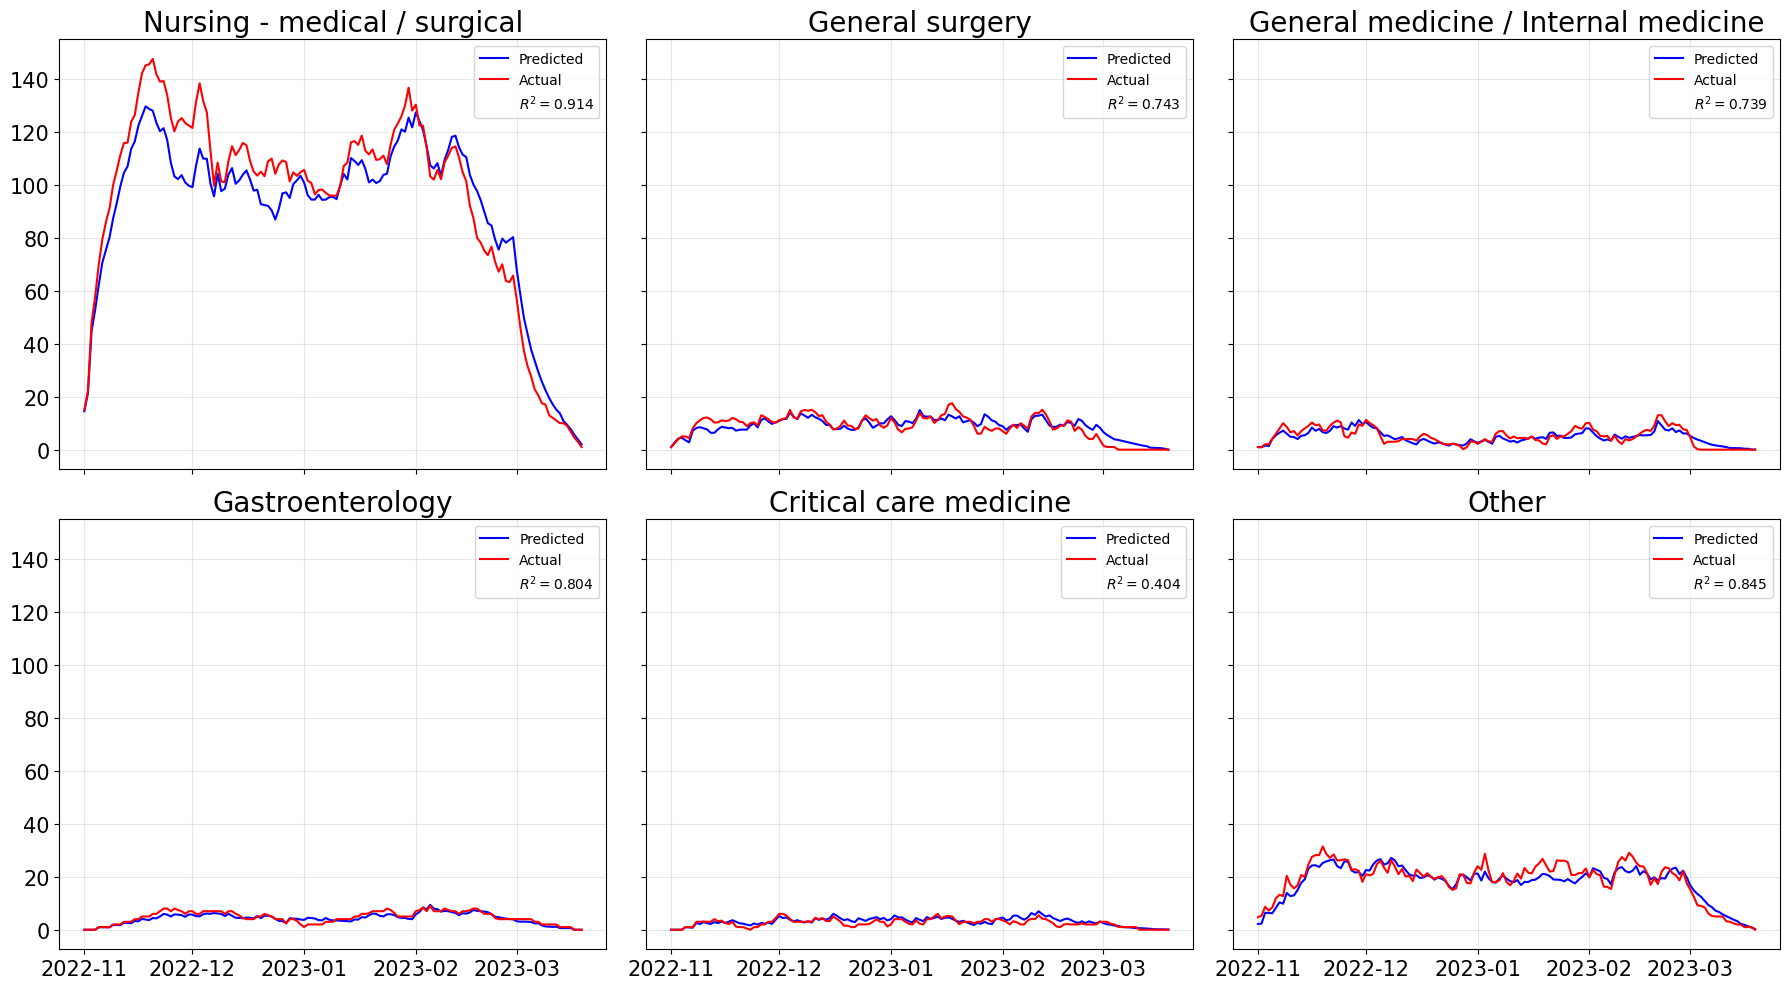

In [72]:
services = predicted_pivot_modified.columns

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10), sharex=True, sharey=True)

for i, service in enumerate(services):
    ax = axes.flat[i]
    ax.plot(predicted_pivot_modified.index, predicted_pivot_modified[service], label='Predicted', color='blue')
    ax.plot(actual_pivot_modified.index, actual_pivot_modified[service], label='Actual', color='red')
    r2 = r2_score(actual_pivot_modified[service], predicted_pivot_modified[service])
    ax.plot([], [], ' ', label=f'$R^2 = {r2:.3f}$')
    ax.set_title(f'{service}')
    ax.legend()
    ax.grid(alpha=0.3)


plt.tight_layout()
plt.savefig("figures/los/predicted_vs_actual_patientloads_by_medical_service.png")

In [73]:
out = (
    df_test.assign(
        los=lambda d: d["encounter_duration_days"].astype(float).clip(upper=los_to_predict),
        full_days=lambda d: np.floor(d["los"]).astype(int),
        rem=lambda d: d["los"] - np.floor(d["los"]),
    )
)

full_part = (
    out.loc[out["full_days"] > 0, ["encounter_start_dt", "full_days"]]
      .assign(day_offset=lambda d: d["full_days"].apply(lambda n: list(range(n))))
      .explode("day_offset")
      .assign(date=lambda d: d["encounter_start_dt"] + pd.to_timedelta(d["day_offset"].astype(int), unit="D"),
              contrib=1.0)[["date", "contrib"]]
)

rem_part = (
    out.loc[out["rem"] > 0, ["encounter_start_dt", "full_days", "rem"]]
      .assign(date=lambda d: d["encounter_start_dt"] + pd.to_timedelta(d["full_days"], unit="D"),
              contrib=lambda d: d["rem"])[["date", "contrib"]]
)

actual_daily_workload = (
    pd.concat([full_part, rem_part], ignore_index=True)
      .groupby("date", as_index=False)["contrib"].sum()
      .rename(columns={"contrib": "workload_bed_days"})
      .sort_values("date")
)

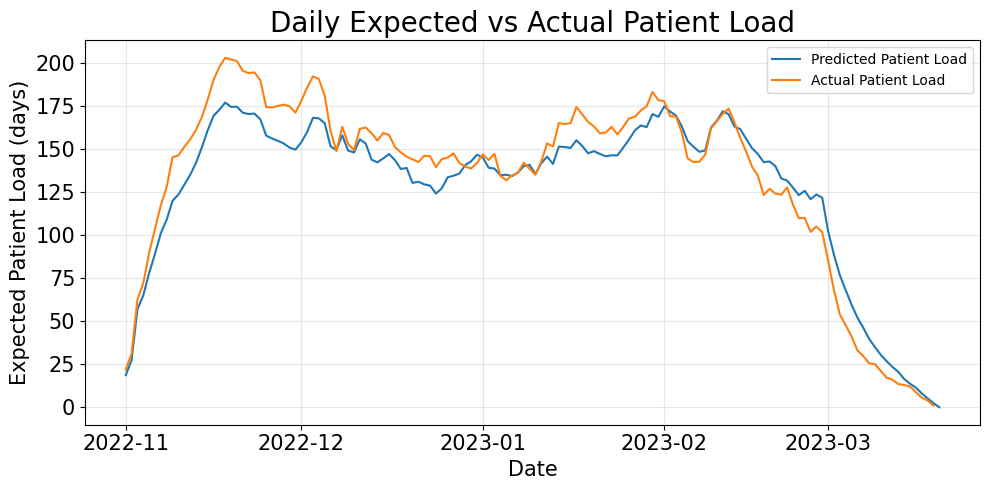

In [74]:
plt.figure(figsize=(10, 5))
plt.plot(daily_workload_df["date"],
         daily_workload_df["expected_workload"],
         label="Predicted Patient Load")

plt.plot(actual_daily_workload["date"],
         actual_daily_workload["workload_bed_days"],
         label="Actual Patient Load")

plt.xlabel("Date", size=15)
plt.ylabel("Expected Patient Load (days)", size=15)
plt.title("Daily Expected vs Actual Patient Load", size=20)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("figures/los/daily_expected_vs_actual_patientload.png")


In [75]:
# Specified categorical columns
categorical_cols = ['encounter_setting', 'encounter_medical_service', 'PATIENT_SEX', 'PATIENT_RACE_ETHNICITY', 'DECEASED_FLAG']

# Collect unique values for each specified column
unique_values = {}
for col in categorical_cols:
    if col in df.columns:
        unique_values[col] = sorted(df[col].dropna().unique().tolist())

# Print the unique values
for col, vals in unique_values.items():
    print(f"{col}: {vals}")

# Optional: Save to CSV
rows = []
for col, vals in unique_values.items():
    for val in vals:
        rows.append({'column_name': col, 'unique_value': val})

unique_df = pd.DataFrame(rows)
unique_df.to_csv('specified_unique_categorical_values.csv', index=False)
print("Unique values saved to 'specified_unique_categorical_values.csv'")

encounter_setting: ['Inpatient', 'Observation', 'Other in person', 'Other unspecified', 'Outpatient']
encounter_medical_service: ['Cardiology', 'Cardiovascular services', 'Cath lab', 'Critical care medicine', 'Emergency medicine', 'Gastroenterology', 'General medicine / Internal medicine', 'General surgery', 'Hematology / Oncology', 'Hospice and palliative medicine', 'Interventional radiology', 'Laboratory', 'Neonatal-Perinatal Medicine', 'Nephrology', 'Neurology', 'Nursing - medical / surgical', 'Obstetrics / Gynecology / Midwifery', 'Orthopedic surgery', 'Other', 'Pediatric hematology/oncology', 'Pediatrics', 'Physical medicine and Rehab', 'Psychiatry / Behavioral health', 'Pulmonology', 'Radiology']
PATIENT_SEX: ['Female', 'Male']
PATIENT_RACE_ETHNICITY: ['American Indian or Alaska Native, non-Hispanic', 'Asian, non-Hispanic', 'Black or African American, non-Hispanic', 'Hispanic', 'Native Hawaiian or Other Pacific Islander, non-Hispanic', 'Unknown/Declined', 'White, non-Hispanic']
D

In [76]:
column_definitions = {
    "patient_id": "Unique identifier for the patient.",
    "encounter_id": "Unique identifier for the healthcare encounter or visit.",
    "icd_prefix3_unique_str": "Comma-separated string of unique 3-character ICD diagnosis code prefixes associated with the encounter.",
    "n_icd_prefix3": "Count of unique 3-character ICD diagnosis code prefixes recorded during the encounter.",
    "encounter_start_dt": "Datetime when the encounter began (first recorded activity or admission).",
    "encounter_end_dt": "Datetime when the encounter ended (final discharge or completion of visit).",
    "encounter_duration_days": "Total length of the encounter in days calculated from encounter start to encounter end.",
    "encounter_setting": "Clinical setting where care occurred (e.g., Inpatient hospitalization, Observation stay, Outpatient visit, or other in-person care setting).",
    "encounter_medical_service": "Primary clinical specialty or hospital service responsible for the encounter (e.g., cardiology, emergency medicine, general surgery).",
    
    "adt_event_types_seq_str": "Chronologically ordered sequence of ADT (Admission, Discharge, Transfer) event types occurring during the encounter, stored as a pipe-separated string.",
    
    "adt_event_times_seq_str": "Chronologically ordered timestamps corresponding to the ADT events in adt_event_types_seq_str.",
    
    "PATIENT_BIRTH_YEAR": "Year of birth for the patient.",
    "PATIENT_SEX": "Recorded sex of the patient (Male or Female).",
    
    "PATIENT_RACE_ETHNICITY": "Recorded patient race and ethnicity category.",
    
    "DECEASED_FLAG": "Binary indicator of whether the patient is recorded as deceased in the dataset (1 = deceased, 0 = not deceased).",
    
    "age": "Patient age in years at the start of the encounter.",
    
    "med_order_nunique": "Number of unique medication orders placed during the encounter.",
    
    "proc_codes_seq_str": "Chronologically ordered pipe-separated list of procedure codes recorded during the encounter.",
    "proc_descs_seq_str": "Chronologically ordered pipe-separated list of procedure descriptions corresponding to proc_codes_seq_str.",
    "proc_times_seq_str": "Chronologically ordered timestamps corresponding to each recorded procedure during the encounter.",
    
    "proc_count": "Total number of procedures performed or recorded during the encounter.",
    
    "past_num_encounters": "Number of encounters recorded for the patient prior to the current encounter.",
    "past_total_procedures": "Total number of procedures recorded across all prior encounters for the patient.",
    "past_total_icd_codes": "Total number of ICD diagnosis codes recorded across all prior encounters.",
    "past_total_encounter_days": "Cumulative number of days spent across all prior encounters.",
}

df_defs = pd.DataFrame(
    [{"column_name": k, "definition": v} for k, v in column_definitions.items()]
)

df_defs.to_csv("encounter_dataset_data_dictionary.csv", index=False)